<a href="https://colab.research.google.com/github/tommiwa/OpenAI_Developer_Crash_Course/blob/main/2_OpenAI_Developer_Crash_Course.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

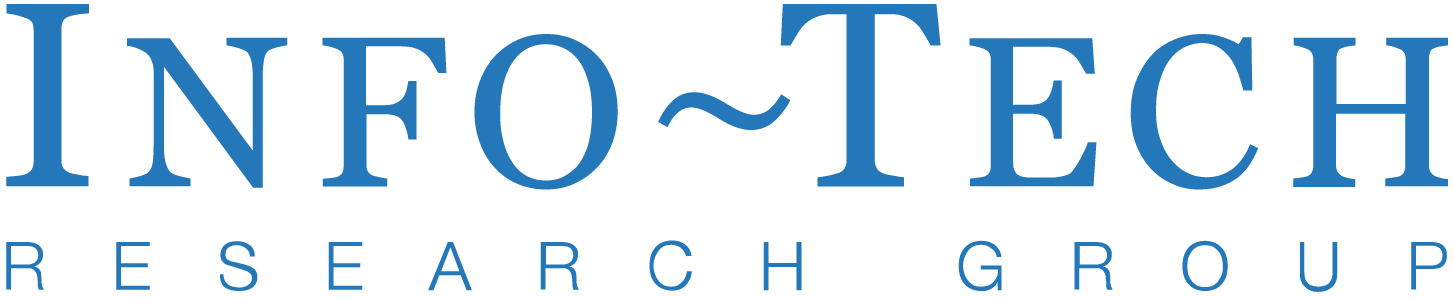

# **Licensing and Proprietary Information Notice**

This notebook is for **Educational purposes** only.

By using this notebook, users agree to respect the intellectual property rights of InfoTech Research Group and to use the provided content and technology in accordance with all applicable laws and regulations.

By uploading any data to the notebook User agrees that uploads will not:

- Include misrepresentative, obscene, libelous, defamatory, threatening, harassing, abusive, hateful, sexually explicit, sexually oriented, profane or embarrassing material, as determined by Info-Tech in its sole discretion;

- Be otherwise objectionable.

### **Limitation of Liability**

> InfoTech disclaims all liability for any actions taken by users outside the educational scope of this course involving the use of this Google Colab notebook. Info-Tech is not liable for any technical issues resulting from use of the Google Colab notebook and User must resolve any technical issues with Google Colab. Should you choose to download this notebook and apply its contents for personal or other uses, you accept full responsibility for any outcomes that arise. InfoTech is not responsible for any direct, indirect, incidental, or consequential damages that may result from such use.


# OpenAI Developer Crash Course 2

After mastering API fundamentals and simple agents in previous part, this part continues by deepening your use of the OpenAI Agents SDK. You'll move from single-agent prototypes to scalable, production-grade agent systems—learning the orchestration patterns, guardrails, and operational practices needed to run agents reliably at global scale. The focus is on turning intelligent tool use into repeatable, observable, and cost-aware workflows.

## Building AI Systems That Take Action

Learn how to build intelligent AI applications with OpenAI's Agents SDK. This comprehensive guide covers:

* Coordinating multiple agents through orchestration patterns
* Tracing (observability)
* Context management
* FinOps token tracking
* Session state and memory

By the end, you'll be equipped to design agentic systems that operate efficiently, safely, and at scale across real-world tasks.


## Prerequisites for Working with OpenAI Agents SDK
Before diving into the OpenAI Agents SDK, it's important to understand several foundational concepts and set up your environment correctly. This section covers everything you need to know before writing your first agent.

### Required knowledge
To get the most out of this tutorial, you should be comfortable with:

*   **Intermediate Python programming**: You should understand functions, classes, async/await patterns, and type hints
*   **Basic OpenAI API usage**: Familiarity with sending requests to OpenAI models and handling responses
*   **Large language models (LLMs)**: Understanding of how LLMs work conceptually and their capabilities/limitations
*   **Pydantic**: Basic knowledge of using Pydantic for data validation will be helpful, as the Agents SDK uses it extensively
*   **Asynchronous programming:** Familiarity with async/await patterns in Python, as the Agents SDK is built around asynchronous execution
*   **Have completed the OpenAI Developer Crash Course 1**: This ensures you're already comfortable with the fundamentals of the OpenAI API, including the Responses API, structured outputs, tools, and streaming. Also, creation and usage of a an agent.

# 1. OpenAI Agents Environment Setup

In [ ]:
%%capture
!pip install openai-agents
!pip install python-dotenv
!pip install openai

In [ ]:
!gdown 1GqMOgE_mQZ-MPwQtdnjtuMVRjYxdgIKe
!gdown 1uElLcArsoyzwXnch25Rr8qS4Zq_HsUfB

## 1.1 Setting up API keys


When working with API keys, it’s a best practice to keep them out of your code. The `python-dotenv` package provides a secure way to manage environment variables:

1.  Create a file named `.env` in your project directory
2.  Add your OpenAI API key to this file:

In [ ]:
import os

from agents import Agent, Runner
from openai import OpenAI
from google.colab import userdata

# Use userdata.get() to securely access the API key from Colab secrets
os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')

client = OpenAI()
response = client.responses.create(
  model="gpt-5",
  input="Tell me a three sentence bedtime story about a unicorn."
)

print(response.output_text)

This approach keeps sensitive information out of your code, which is especially important if you’re sharing or publishing your work.

# 2. Agents Refersher


An **Agent** is a model with clear **instructions** (role & rules) and optional tools. You interact with it by calling `Runner.run(agent, "your prompt")`, and you get back the model’s final answer.

**When to use it**

* Fast “ask/answer” helpers
* Task-focused assistants with a tight role (e.g., “be concise, be factual”)
* The building block you'll later extend with tools, memory, and orchestration

**Keep in mind**

* **instructions** act like a system prompt—be specific and brief
* **model** defines capability/cost/latency (e.g., `gpt-5`, `gpt-5-mini`, `gpt-5-nano`)
* Calls are **async**; in notebooks you can `await` directly

In [ ]:
from agents import Agent, Runner

# 1) Define the agent’s role
assistant = Agent(
    name="Helper",
    instructions=(
        "You are a concise, factual assistant. "
        "If you aren't sure, say you are uncertain. "
        "Prefer 2–4 short sentences."
    ),
    model="gpt-5"
)

# 2) Run it on a prompt
result = await Runner.run(assistant, "Give me a quick definition of vector databases.")
print(result.final_output)


# 3. Tracing

The Agents SDK includes built-in tracing, collecting a comprehensive record of events during an agent run: LLM generations, tool calls, handoffs, guardrails, and even custom events that occur. Using the [Traces dashboard](https://platform.openai.com/logs?api=traces) (visible for free in the OpenAI platform), you can debug, visualize, and monitor your workflows during development and in production.

**Note:**

Tracing is enabled by default. There are two ways to disable tracing:

*   You can globally disable tracing by setting the env var `OPENAI_AGENTS_DISABLE_TRACING=1`
*   You can disable tracing for a single run by setting `agents.run.RunConfig.tracing_disabled` to `True`

For organizations operating under a Zero Data Retention (ZDR) policy using OpenAI's APIs, tracing is unavailable.



## 3.1 Creating traces



You can use the `trace()` function to create a trace. Traces need to be started and finished. You have two options to do so:

*   **Recommended:** use the trace as a context manager, i.e. `with trace(...) as my_trace`. This will automatically start and end the trace at the right time.
*   You can also manually call `trace.start()` and `trace.finish()`.

The current trace is tracked via a Python contextvar. This means that it works with concurrency automatically. If you manually start/end a trace, you'll need to pass `mark_as_current` and `reset_current` to `start()`/`finish()` to update the current trace.

## 3.2 Sensitive data


Certain spans may capture potentially sensitive data.

The `generation_span()` stores the inputs/outputs of the LLM generation, and `function_span()` stores the inputs/outputs of function calls. These may contain sensitive data, so you can disable capturing that data via `RunConfig.trace_include_sensitive_data`.

Similarly, Audio spans include base64-encoded PCM data for input and output audio by default. You can disable capturing this audio data by configuring `VoicePipelineConfig.trace_include_sensitive_audio_data`.

## 3.3 Tracing Example

In [ ]:
from agents import Agent, Runner, trace, gen_trace_id

async def main():
    agent = Agent(
        name="Joke generator",
        instructions="Tell funny jokes.",
        model="gpt-5-mini",
    )
    trace_id = gen_trace_id()

    with trace("Joke Worfklow", trace_id=trace_id):
      print(f"🔍 View Trace: [OpenAI Platform](https://platform.openai.com/traces/trace?trace_id={trace_id})\n")
      first_result = await Runner.run(agent, "Tell a joke")
      second_result = await Runner.run(agent, f"Rate this joke: {first_result.final_output}")
      print(f"Joke: {first_result.final_output}")
      print(f"Rating: {second_result.final_output}")

await main()

### Insights

Tracing gives you a live, end-to-end timeline of each agent run—LLM generations, tool calls, handoffs, guardrails, and custom spans—visible in the Traces dashboard, so when you have many agents running in parallel you can quickly review traces to find failures, compare runs, and spot latency. It’s built into the Agents SDK for single- and multi-agent workflows, with eval support (trace grading) for systematic debugging; you can exclude sensitive data (including audio) or disable tracing per run or via an env var, and organizations on Zero Data Retention won’t have tracing.

# 4. Guardrails

## 4.1 Agents SDK Guardrails

OpenAI's **Moderation API** can screen both **user inputs** and **model outputs**. Below we wrap a normal agent run with a simple pre-check and post-check using `omni-moderation-latest`.

- If the input is flagged → block and ask the user to rephrase.
- If the output is flagged → block the reply.

 For larger apps, prefer the Agents SDK **guardrails** pattern—implemented as **decorators**—so unsafe requests never reach expensive models. Use `@input_guardrail` for pre-checks and `@output_guardrail` for post-checks; these run **in parallel** to the agent and raise **tripwire** exceptions to halt unsafe runs early. See the official Moderation and Guardrails docs for details. ([OpenAI Cookbook][1], [Agents SDK Guardrails][2])

[1]: https://cookbook.openai.com/examples/how_to_use_moderation "How to use the moderation API"
[2]: https://openai.github.io/openai-agents-python/guardrails/ "Guardrails - OpenAI Agents SDK"
[1]: https://cookbook.openai.com/examples/how_to_use_moderation "How to use the moderation API"


In [ ]:
from agents import (
    Agent, Runner, RunContextWrapper, GuardrailFunctionOutput,
    input_guardrail, output_guardrail,
    InputGuardrailTripwireTriggered, OutputGuardrailTripwireTriggered,
)
from pydantic import BaseModel
from openai import OpenAI

client = OpenAI()

class Msg(BaseModel):
    response: str

@input_guardrail
async def moderate_input(ctx: RunContextWrapper[None], agent: Agent, input: str | list) -> GuardrailFunctionOutput:
    r = client.moderations.create(model="omni-moderation-latest", input=input if isinstance(input, str) else str(input))

    return GuardrailFunctionOutput(output_info={"flagged": r.results[0].flagged},
                                   tripwire_triggered=r.results[0].flagged)

@output_guardrail
async def moderate_output(ctx: RunContextWrapper, agent: Agent, output: Msg) -> GuardrailFunctionOutput:
    r = client.moderations.create(model="omni-moderation-latest", input=output.response)

    return GuardrailFunctionOutput(output_info={"flagged": r.results[0].flagged},
                                   tripwire_triggered=r.results[0].flagged)

agent = Agent(
    name="Guarded",
    instructions="Be helpful and brief.",
    model="gpt-5-mini",
    input_guardrails=[moderate_input],
    output_guardrails=[moderate_output],
    output_type=Msg,
)

try:
    input_text = "Say hello to the class!"
    result = await Runner.run(agent, input_text)
    print(result.final_output.response)
except (InputGuardrailTripwireTriggered, OutputGuardrailTripwireTriggered):
    print("❌ Blocked by moderation.")


### 🎯 Activity: Try to trigger the input guardrail and then check on the agent trace on the dashboard to see it

### Insights ⭐
Guardrails keep multi-agent systems safe, consistent, and cost-efficient: screen inputs/outputs with the Moderation API, layer SDK guardrails to block unsafe runs before expensive calls, and add standard controls like schema validation, allow/deny lists, rate limits, and tool guardrails (whitelist tools/arguments or validate params). When many agents run concurrently, these checks—paired with tracing—make it easy to review failures, spot patterns, and halt bad workflows early for FinOps and compliance.

# 5. Agent Orchestration

## 5.1 What “orchestration” means

Orchestration refers to the flow of agents in your app. Which agents run, in what order, and how do they decide what happens next? There are two main ways to orchestrate agents:

1. Allowing the LLM to make decisions: this uses the intelligence of an LLM to plan, reason, and decide on what steps to take based on that.

2. Orchestrating via code: determining the flow of agents via your code.

You can mix and match these patterns. Each has their own tradeoffs, described below.

## 5.2 Orchestration modes

### Orchestrating via code

While orchestrating via LLM is powerful, orchestrating via code makes tasks more deterministic and predictable, in terms of speed, cost and performance. Common patterns here are:

- Using structured outputs to generate well formed data that you can inspect with your code. For example, you might ask an agent to classify the task into a few categories, and then pick the next agent based on the category.
- Chaining multiple agents by transforming the output of one into the input of the next. You can decompose a task like writing a blog post into a series of steps - do research, write an outline, write the blog post, critique it, and then improve it.
- Running the agent that performs the task in a while loop with an agent that evaluates and provides feedback, until the evaluator says the output passes certain criteria.
- Running multiple agents in parallel, e.g. via Python primitives like asyncio.gather. This is useful for speed when you have multiple tasks that don't depend on each other.

In [ ]:
import asyncio
from typing import Annotated
from pydantic import BaseModel, Field
from agents import Agent, Runner, trace, gen_trace_id

"""
This example demonstrates a orchestration via code, where each step is performed by an agent.
1. The first agent generates a story outline
2. We feed the outline into the second agent
3. The second agent checks if the outline is good quality and if it is a scifi story
4. If the outline is not good quality or not a scifi story, we stop here
5. If the outline is good quality and a scifi story, we feed the outline into the third agent
6. The third agent writes the story
"""

story_outline_agent = Agent(
    name="story_outline_agent",
    instructions="Generate a very short story outline based on the user's input.",
    model="gpt-5-mini",
)


class OutlineCheckerOutput(BaseModel):
    good_quality: Annotated[bool, Field(..., description="True if outline has good quality.")]
    is_scifi: Annotated[bool, Field(..., description="True if outline is a sci-fi story.")]


outline_checker_agent = Agent(
    name="outline_checker_agent",
    instructions="Read the given story outline, and judge the quality. Also, determine if it is a scifi story.",
    model="gpt-5-mini",
    output_type=OutlineCheckerOutput,
)

story_agent = Agent(
    name="story_agent",
    instructions="Write a short story based on the given outline.",
    model="gpt-5-mini",
)

async def main():
    input_prompt = input("What kind of story do you want? ")

    trace_id = gen_trace_id()
    # Ensure the entire workflow is a single trace
    with trace("Deterministic story flow", trace_id=trace_id):
        print(f"🔍 View Trace: [OpenAI Platform](https://platform.openai.com/traces/trace?trace_id={trace_id})\n")
        # 1. Generate an outline
        outline_result = await Runner.run(
            story_outline_agent,
            input_prompt,
        )
        print("Outline generated")

        # 2. Check the outline
        outline_checker_result = await Runner.run(
            outline_checker_agent,
            outline_result.final_output,
        )

        # 3. Add a gate to stop if the outline is not good quality or not a scifi story
        assert isinstance(outline_checker_result.final_output, OutlineCheckerOutput)
        if not outline_checker_result.final_output.good_quality:
            print("Outline is not good quality, so we stop here.")
            # In a Jupyter notebook, we don't exit the kernel
            return

        if not outline_checker_result.final_output.is_scifi:
            print("Outline is not a scifi story, so we stop here.")
            # In a Jupyter notebook, we don't exit the kernel
            return

        print("Outline is good quality and a scifi story, so we continue to write the story.")

        # 4. Write the story
        story_result = await Runner.run(
            story_agent,
            outline_result.final_output,
        )
        print(f"Story: {story_result.final_output}")
        return

await main()


### 🎯 Activity: Try running with different inputs.

### Orchestrating via LLM
Orchestration via LLM allows an agent to autonomously plan and execute tasks using its instructions, tools, and handoffs.

*   **Capabilities:** Agents can use tools (Web search, File search, Computer use, Code execution) and handoffs to specialists.
*   **Use Case:** Ideal for open-ended tasks where you leverage the LLM's intelligence.
*   **Key Tactics:**
    1. Invest in good prompts. Make it clear what tools are available, how to use them, and what parameters it must operate within.
    2. Monitor your app and iterate on it. See where things go wrong, and iterate on your prompts.
    3. Allow the agent to introspect and improve. For example, run it in a loop, and let it critique itself; or, provide error messages and let it improve.
    4. Have specialized agents that excel in one task, rather than having a general purpose agent that is expected to be good at anything.
    5. Invest in evals. This lets you train your agents to improve and get better at tasks.

#### Agents Handoffs

In complex applications, different tasks often require different areas of expertise. The OpenAI Agents SDK supports “handoffs,” which allow one agent to delegate control to another specialized agent. This feature is particularly valuable when building systems that handle diverse user requests, such as customer support applications where different agents might handle billing inquiries, technical support, or account management.

In [ ]:
from agents import Agent, handoff, RunContextWrapper, Runner
from datetime import datetime

# --- Specialist Agents (from the university example) ---

academic_advising_agent = Agent(
    name="Academic Advising Agent",
    instructions="""
    You help students with course selection, degree planning, and academic policies.
    If the request is technical or about administrative records, refer to the right team.
    """,
    model="gpt-5-mini",
)

it_support_agent = Agent(
    name="IT Support Agent",
    instructions="""
    You handle technology issues such as login problems, access to online platforms,
    and device/software troubleshooting. Focus on tech issues only.
    """,
    model="gpt-5-mini",
)

student_records_agent = Agent(
    name="Student Records",
    instructions="""
    You handle administrative record changes such as legal name updates, transcripts,
    enrollment verifications, and personal info changes (address, preferred name).
    If the issue is technical (e.g., password reset) or academic planning, refer out.
    """,
    model="gpt-5-mini",
)

# --- Custom handoff callback ---

async def log_student_records_handoff(ctx: RunContextWrapper[None]):
    print(f"[LOG] Student Records handoff at {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    # In production, write to your logging system / audit trail / notify a coordinator.

# --- Enhanced Triage Agent with customized handoffs ---

enhanced_help_desk_agent = Agent(
    name="Enhanced University Help Desk",
    instructions="""
    You are the initial university help desk contact who routes inquiries appropriately.

    - Academic planning or course/degree questions → Academic Advising Agent.
    - Technology or login/access issues → IT Support Agent.
    - Administrative records (legal name change, transcripts, enrollment verification, profile updates) → Student Records.
    - General campus questions (hours, locations, events) → answer directly.

    Always be polite and provide a smooth, clear transition when handing off.
    """,
    model="gpt-5",
    handoffs=[
        academic_advising_agent,  # Basic handoff
        handoff(                   # Customized handoff with logging + custom tool name/description
            agent=student_records_agent,
            on_handoff=log_student_records_handoff,
            tool_name_override="escalate_to_student_records",
            tool_description_override=(
                "Transfer to Student Records for legal name changes, transcripts, enrollment verifications, "
                "and personal information updates."
            ),
        ),
        it_support_agent,         # Basic handoff
    ],
)

# --- Example run (uses Student Records to demonstrate the custom callback) ---

async def main():
    runner = Runner()
    result = await runner.run(
        enhanced_help_desk_agent,
        "I need to update my legal name on my student record."
    )
    print(result.final_output)

await main()

### 🎯 Activity: Try changing user prompt to trigger handoff to different agents.

#### Agents as Tools


The Agents SDK allows you to use agents themselves as tools, enabling a hierarchical structure where specialist agents work under a coordinator. This is a powerful pattern for complex workflows. Convert specialists to tools using `.as_tool()`, defining `tool_name` and `tool_description`. Allows for complex systems with clear separation of concerns and specialized expertise managed by a coordinator.

In [ ]:
from agents import Agent, Runner

# --- Specialist Agents ---

flight_search_agent = Agent(
    name="Flight Finder",
    instructions="You help users find and compare flights based on price, schedule, and airline preferences.",
    model="gpt-5-mini",
    # In a real application, connect this to a flight API
)

activity_planner_agent = Agent(
    name="Activity Planner",
    instructions="You help users find fun, interesting, and relevant activities at their travel destination.",
    model="gpt-5-mini",
    # In a real application, connect this to an activities/events database
)

# --- Coordinator Agent (Travel Assistant) ---

travel_assistant = Agent(
    name="Travel Assistant",
    instructions=(
        "You are a travel assistant that helps users plan trips.\n\n"
        "For finding flights, use the flight_search tool.\n"
        "For suggesting activities, use the activity_planner tool.\n\n"
        "Decide which tool is best based on the user's request, "
        "and help them coordinate between transportation and activities."
    ),
    model="gpt-5",
    tools=[
        flight_search_agent.as_tool(
            tool_name="flight_search",
            tool_description="Find and compare flights based on user needs"
        ),
        activity_planner_agent.as_tool(
            tool_name="activity_planner",
            tool_description="Suggest activities and attractions at the destination"
        )
    ]
)


async def main():
    runner = Runner()
    query = "I’m going to Tokyo next month. Can you suggest things to do?"

    result = await runner.run(travel_assistant, query)
    print(result.final_output)

await main()

### Code Orchestration vs. Handoffs vs Agents as Tools


Agents can coordinate in three ways: **code orchestration**, **handoffs**, and **agents-as-tools**. Pick based on how much determinism you need, how much context to share, and who should remain “in control” of the conversation.

**Use code orchestration when:**

- Need deterministic routing and predictable latency/cost

- Want code to control flow; agents return structured outputs

- Chain explicit steps with transformations between agents

- Require strong observability, retries, and fallbacks

- Prefer a pro-code posture for compliance/reliability

**Use handoffs when:**

- You want to fully transfer control to another agent

- Want to share all chat history with new agent

- A specialist needs to continue the conversation

- Different stages of a workflow are handled by different agents

**Use agents-as-tools when:**

- The main agent stays in control but consults a specialist

- Want to share only last message

- The specialist’s output is part of a larger answer

- You’re building a hierarchy where a coordinator delegates subtasks

You can also **combine all three**: a main agent might sometimes consult a specialist (tool), other times hand off control entirely, and in many cases be sequenced or supervised via code.

**Tip:** Use code orchestration for determinism, compliance, and system-level control; handoffs for clean responsibility boundaries and full context transfer; and tools to inject expertise while the main agent keeps the wheel.

### Insights ⭐
Agent orchestration is how you control which agents run, in what order, and who decides next steps—either letting an LLM plan with tools and handoffs to specialists, or enforcing a deterministic flow in code (often mixing both). In practice, you can delegate work via handoffs or keep a coordinator in charge by using agents-as-tools; pair this with tracing to review runs at scale, compare paths, and spot latency/usage hotspots.

## [Optional] 5.6 Common Agentic Orchestration Patterns

### Deterministic

A common tactic is to break down a task into a series of smaller steps. Each task can be performed by an agent, and the output of one agent is used as input to the next. Each of the steps can be performed by an agent. The output of one agent is used as input to the next.

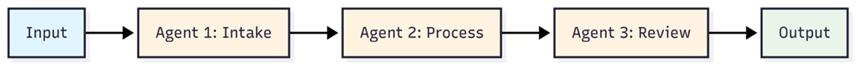

### Routing

In many situations, you have specialized sub-agents that handle specific tasks. You can use handoffs to route the task to the right agent.

For example, you might have a frontline agent that receives a request, and then hands off to a specialized agent based on the language of the request.

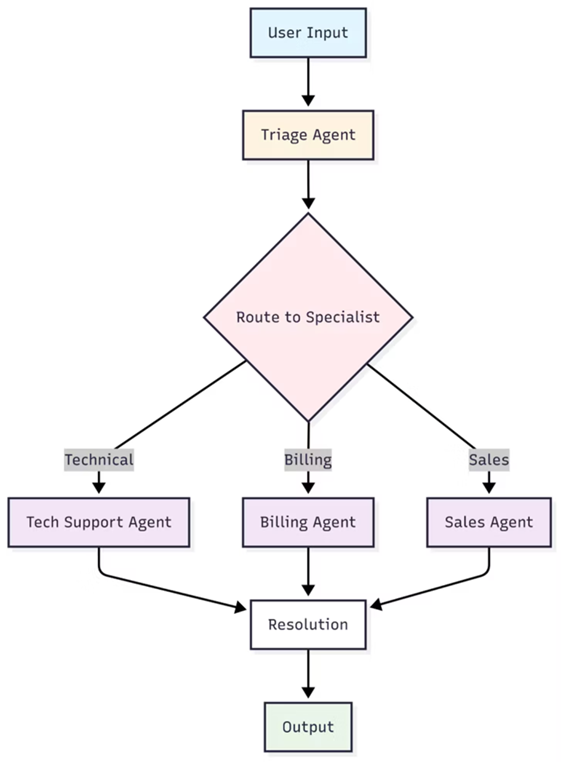

### Agents as tools

The mental model for handoffs is that the new agent "takes over". It sees the previous conversation history, and owns the conversation from that point onwards. However, this is not the only way to use agents. You can also use agents as a tool - the tool agent goes off and runs on its own, and then returns the result to the original agent.

For example, you could model the translation task above as tool calls instead: rather than handing over to the language-specific agent, you could call the agent as a tool, and then use the result in the next step. This enabQles things like translating multiple languages at once.

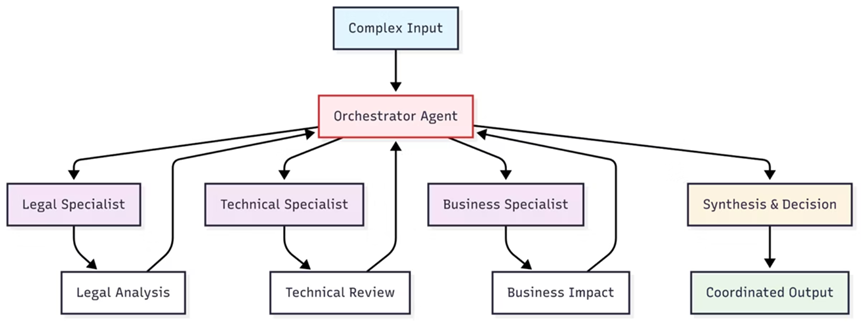

### LLM-as-a-judge

LLMs can often improve the quality of their output if given feedback. A common pattern is to generate a response using a model, and then use a second model to provide feedback. You can even use a small model for the initial generation and a larger model for the feedback, to optimize cost.

For example, you could use an LLM to generate an outline for a story, and then use a second LLM to evaluate the outline and provide feedback. You can then use the feedback to improve the outline, and repeat until the LLM is satisfied with the outline.

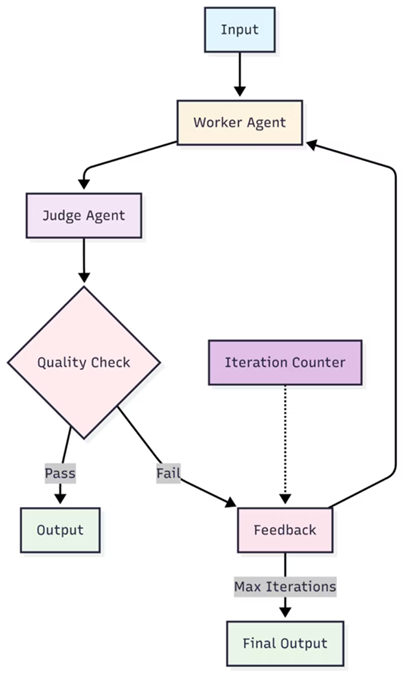

### Parallelization

Running multiple agents in parallel is a common pattern. This can be useful for both latency (e.g. if you have multiple steps that don't depend on each other) and also for other reasons e.g. generating multiple responses and picking the best one.




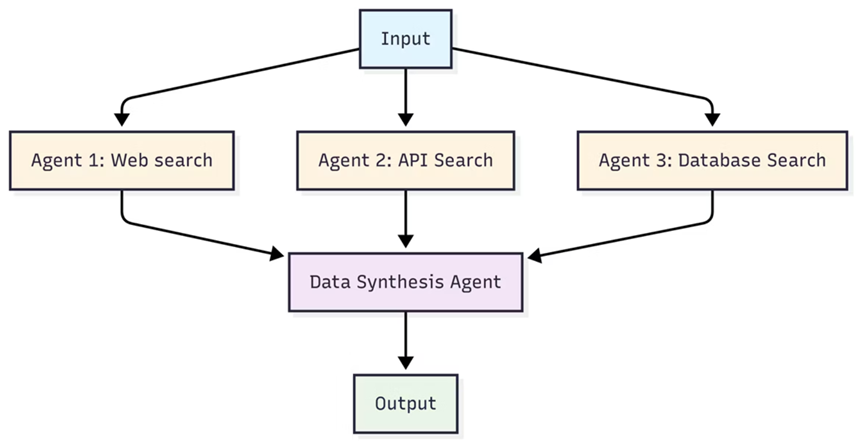

# 6. Agent Lifecycle with Hooks and Token Counting

Hooks give you observability and control over every stage of a run. With `RunHooks` you can listen for agent start/end, tool start/end, and handoffs to log events, attach traces, and enforce policies in one place. Paired with the `Usage` object (requests/input/output/total tokens), you can implement budget guards (per-run or per-user), circuit breakers (e.g., abort on too many tool calls or tokens), and quality gates (retry, escalate, or hand off when certain conditions are met). In practice, hooks turn orchestration from “fire-and-forget” into a monitored pipeline you can test, alert, and audit.

Token counting is the backbone of cost/latency control. By reading usage inside hooks, you can cap steps, stop recursion, switch to cheaper models for low-risk turns, or compress inputs when token pressure rises. Combined with tracing, this yields a clear audit trail across agents, tools, and handoffs—crucial when debugging complex workflows or reporting spend.


In [ ]:
import asyncio
import random
from typing import Any

from pydantic import BaseModel

from agents import Agent, RunContextWrapper, RunHooks, Runner, Tool, Usage, function_tool, trace, gen_trace_id, AgentHooks


class ExampleHooks(RunHooks):
    def __init__(self):
        self.event_counter = 0

    def _usage_to_str(self, usage: Usage) -> str:
        return f"{usage.requests} requests, {usage.input_tokens} input tokens, {usage.output_tokens} output tokens, {usage.total_tokens} total tokens"

    async def on_agent_start(self, context: RunContextWrapper, agent: Agent) -> None:
        self.event_counter += 1
        print(
            f"### {self.event_counter}: Agent {agent.name} started. Usage: {self._usage_to_str(context.usage)}"
        )

    async def on_agent_end(self, context: RunContextWrapper, agent: Agent, output: Any) -> None:
        self.event_counter += 1
        print(
            f"### {self.event_counter}: Agent {agent.name} ended with output {output}. Usage: {self._usage_to_str(context.usage)}"
        )

    async def on_tool_start(self, context: RunContextWrapper, agent: Agent, tool: Tool) -> None:
        self.event_counter += 1
        print(
            f"### {self.event_counter}: Tool {tool.name} started. Usage: {self._usage_to_str(context.usage)}"
        )

    async def on_tool_end(
        self, context: RunContextWrapper, agent: Agent, tool: Tool, result: str
    ) -> None:
        self.event_counter += 1
        print(
            f"### {self.event_counter}: Tool {tool.name} ended with result {result}. Usage: {self._usage_to_str(context.usage)}"
        )

    async def on_handoff(
        self, context: RunContextWrapper, from_agent: Agent, to_agent: Agent
    ) -> None:
        self.event_counter += 1
        print(
            f"### {self.event_counter}: Handoff from {from_agent.name} to {to_agent.name}. Usage: {self._usage_to_str(context.usage)}"
        )


hooks = ExampleHooks()

@function_tool
def random_number(max: int) -> int:
    """Generate a random number up to the provided max."""
    return random.randint(0, max)


@function_tool
def multiply_by_two(x: int) -> int:
    """Return x times two."""
    return x * 2


class FinalResult(BaseModel):
    number: int


multiply_agent = Agent(
    name="Multiply Agent",
    instructions="Multiply the number by 2 and then return the final result.",
    tools=[multiply_by_two],
    output_type=FinalResult,
)

start_agent = Agent(
    name="Start Agent",
    instructions="Generate a random number. If it's even, stop. If it's odd, hand off to the multiplier agent.",
    tools=[random_number],
    output_type=FinalResult,
    handoffs=[multiply_agent],
)


async def main() -> None:
    user_input = input("Enter a max number: ")
    trace_id = gen_trace_id()
    print(f"🔍 View Trace: [OpenAI Platform](https://platform.openai.com/traces/trace?trace_id={trace_id})\n")
    with trace("Lifecycle example", trace_id=trace_id):
        await Runner.run(
            start_agent,
            hooks=hooks,
            input=f"Generate a random number between 0 and {user_input}.",
        )

await main()

### 🎯 [Optional] Activity: Add new tool `add_two_numbers` introduce it to the start agent. Update prompts for start agent to create 2 numbers and add them together before using multiply agent.

# 7. Session/Memory


Sessions provide durable conversation state across runs so an agent can “remember” prior messages without you manually piping history around. A `Session` implementation (e.g., `SQLiteSession`) stores and retrieves the evolving transcript, letting you build multi-turn experiences—follow-up questions, references to “that result,” and long tasks—while still honoring token and cost limits.

Good memory hygiene matters: keep evergreen rules in instructions, pass request-specific details via input, and let sessions hold only what benefits the next turn. Prune or summarize older content to control context size; reload full detail via retrieval when needed. Sessions complement (not replace) retrieval/web/MCP tools: use memory for dialogue continuity and user preferences, and use tools to fetch fresh or authoritative facts.

In [ ]:
import asyncio

from agents import Agent, Runner, SQLiteSession


async def main():
    # Create an agent
    agent = Agent(
        name="Assistant",
        instructions="Reply very concisely.",
    )

    # Create a session instance that will persist across runs
    session_id = "conversation_123"
    session = SQLiteSession(session_id)

    print("=== Session Example ===")
    print("The agent will remember previous messages automatically.\n")

    # First turn
    print("First turn:")
    print("User: What city is the Golden Gate Bridge in?")
    result = await Runner.run(
        agent,
        "What city is the Golden Gate Bridge in?",
        session=session,
    )
    print(f"Assistant: {result.final_output}")
    print()

    # Second turn - the agent will remember the previous conversation
    print("Second turn:")
    print("User: What state is it in?")
    result = await Runner.run(
        agent,
        "What state is it in?",
        session=session
      )
    print(f"Assistant: {result.final_output}")
    print()

    # Third turn - continuing the conversation
    print("Third turn:")
    print("User: What's the population of that state?")
    result = await Runner.run(
        agent,
        "What's the population of that state?",
        session=session,
    )
    print(f"Assistant: {result.final_output}")
    print()

    if session is None:
        return

    print("=== Conversation Complete ===")
    print("Notice how the agent remembered the context from previous turns!")
    print("Sessions automatically handles conversation history.")



    # Demonstrate the limit parameter - get only the latest 2 items
    print("\n=== Latest Items Demo ===")
    latest_items = await session.get_items(limit=2)
    print("Latest 2 items:")
    for i, msg in enumerate(latest_items, 1):
        role = msg.get("role", "unknown")
        content = msg.get("content", "")
        print(f"  {i}. {role}: {content}")

    print(f"\nFetched {len(latest_items)} out of total conversation history.")

    # Get all items to show the difference
    all_items = await session.get_items()
    print(f"Total items in session: {len(all_items)}")

await main()

# 8. Coding Task

Now it's your turn to build an agent! Your task is to create a single agent that can process images, perform basic calculations, and retrieve information from a vector database.

You'll need to equip your agent with three tools:

1.  **Image Processing Tool**: This tool should be able to analyze a local image file based on a given instruction. You have access to a local image file named `/content/part.PNG` that you can use.
2.  **Basic Calculation Tool**: This tool should perform simple mathematical operations (addition, subtraction, multiplication, division) on two numbers.
3.  **Vector Database Retrieval Tool**: This tool should search a vector database (`vs_***`) to find relevant information based on a query. This vector db has information on the agentic prototyping workshop like schedule, learning outcomes and day to day activities. (As seen in the OpenAI API crash course). Upload the PDF into the OpenAI VectorDB and use that.

Your agent should use these tools to answer the following question:

`"Multiply the number of days in the agentic workshop by the height in mm (displayed) of this object found on this CAD image: '/content/part.PNG'."`

You will need to use the appropriate tools to:
*   Find the number of days in the workshop (using the vector database).
*   Find the height of the object (in mm) in the image (using the gen ai image processing tool).
*   Perform the multiplication (using the calculation tool).


Good luck!

In [ ]:
import base64
from typing import Optional
import random # Import random to simulate varying search results
from pydantic import BaseModel
from agents import Agent, Runner, function_tool, Tool, gen_trace_id, trace
from openai import OpenAI

# Initialize the OpenAI client (ensure API key is set in environment variables)
client = OpenAI()

# Define a Pydantic model for the desired output
class CalculationResult(BaseModel):
    """The final calculated number."""
    # TODO: add in the final number
    # =========== TODO START =============

    # ============ TODO END ==============

# Function to encode the image (helper function)
def encode_image(image_path):
    """Encodes a local image file to a base64 string."""
    try:
        with open(image_path, "rb") as image_file:
            return base64.b64encode(image_file.read()).decode("utf-8")
    except FileNotFoundError:
        return f"Error: Image file not found at {image_path}"
    except Exception as e:
        return f"Error encoding image: {e}"

# =========== TODO START =============
# TODO: Turn into a tool.
# Tool 1: Image Processing (using OpenAI API with local file)

# ============ TODO END ==============
def process_image(image_path: str, instruction: str) -> str:
    """
    Processes a local image file based on a given instruction using OpenAI's API.
    Expects the image as a local file path.
    Returns a description or result of the processing.
    """
    print(f"Processing local image from path: {image_path} with instruction: '{instruction}'")
    # Getting the Base64 string
    base64_image = encode_image(image_path)

    if base64_image.startswith("Error"):
        return base64_image # Return error message if encoding failed

    try:
        response = client.responses.create(
            model="gpt-5",
            instructions="You are a helpful assistant that analyzes images.", # Can be customized based on instruction
            input=[
                {"role": "user", "content": instruction}, # Use the provided instruction
                {
                    "role": "user",
                    "content": [
                         { "type": "input_text", "text": instruction }, # Include instruction as text input
                         {
                             "type": "input_image",
                             "image_url": f"data:image/jpeg;base64,{base64_image}", # Use base64 data
                             "detail": "high" # Optional detail level
                         },
                    ],
                },
            ],
        )

        if response.output_text:
            return response.output_text
        else:
            return "Image processing completed, but no descriptive text was returned."

    except Exception as e:
        return f"Error during image processing: {e}"

# =========== TODO START =============
# TODO: Turn into a tool.
# Tool 2: Basic Calculation

# ============ TODO END ==============
def perform_calculation(number1: float, number2: float, operation: str) -> str: # Changed return type to str to handle errors
    """
    Performs a basic mathematical calculation between two numbers.
    Args:
        number1: The first number.
        number2: The second number.
        operation: The operation to perform ('add', 'subtract', 'multiply', 'divide').
    """
    if operation == 'add':
        return str(number1 + number2)
    elif operation == 'subtract':
        return str(number1 - number2)
    elif operation == 'multiply':
        return str(number1 * number2)
    elif operation == 'divide':
        if number2 == 0:
            return "Error: Division by zero"
        return str(number1 / number2)
    else:
        return f"Error: Unsupported operation '{operation}'. Supported operations are 'add', 'subtract', 'multiply', 'divide'."

# =========== TODO START =============
# TODO: Turn into a tool.
# Tool 3: Vector Database Retrieval (Real implementation using OpenAI File Search)
# Note: Make sure to upload the PDF for vector storage found in the files to the left.

# ============ TODO END ==============
def retrieve_from_vector_db(query: str, max_num_results: int = 5) -> str:
    """
    Retrieves relevant information from the AIWD agentic prototyping workshop database based on a query using OpenAI File Search.
    Args:
        query: The search query.
        max_num_results: The maximum number of results to return.
    """
    print(f"Searching the AIWD agentic prototyping workshop database for query: '{query}'")

    try:
        response = client.responses.create(
            model="gpt-5", # Use a model that supports file search
            input=query,
            tools=[{
                "type": "file_search",
                # =========== TODO START =============
                "vector_store_ids": ["TODO"], # Use the specified VECTOR STORE ID
                # ============ TODO END ==============
                "max_num_results": max_num_results
            }],
            include=["file_search_call.results"]
        )

        response_text = f"Here are some relevant results from the AIWD agentic prototyping workshop database for your query: '{query}'\n\n"
        citations_text = "Citations:\n"
        has_results = False

        if response.output:
            for item in response.output:
                if item.type == "message":
                    for content_item in item.content:
                        if content_item.type == "output_text":
                            if content_item.text:
                                response_text += content_item.text + "\n"
                                has_results = True
                            if content_item.annotations:
                                for annotation in content_item.annotations:
                                    if annotation.type == "file_citation":
                                        citations_text += f"- File: {annotation.filename}, File ID: {annotation.file_id}\n"
                                        has_results = True


        if not has_results:
             response_text += "No relevant documents found."
        return response_text + "\n" + citations_text

    except Exception as e:
        return f"Error during vector database search: {e}"



# Create an Agent that uses these tools
multimodal_agent = Agent(
    name="Multimodal Processor",
    # =========== TODO START =============
    instructions="""You are a versatile assistant capable of...""", # TODO: modify instructions
    tools=[], # TODO: add tools.
    model="", # TODO: Select model
    output_type=CalculationResult, # Set the output type to the Pydantic model for calculations
    # ============ TODO END ==============
)

print("Agent with image processing, calculation, and vector DB tools created and configured for structured output.")

In [ ]:
async def run_multimodal_agent(query: str):
    runner = Runner()
    # =========== TODO START =============
    # TODO: generate trace id
    # TODO: add with trace statement
        # TODO: print trace id
        # TODO: run agent
        result = TODO
        print(f"Agent Response: {result.final_output}")
    # ============ TODO END ==============

# Run the agent with the user's query
await run_multimodal_agent("multiply the number of days in the agentic workshop by the height in mm (displayed) of this object found on this CAD image: '/content/part.PNG'. ")